# Notebook to plot April Snow Depth anomaly
- Jeamilett Martinez, Kristina Black, Alice DuVivier
- April 2026

## Import the python modules we'll need

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import glob
from scipy.stats import ttest_1samp
from scipy.stats import percentileofscore
import matplotlib.pyplot as plt
import netCDF4 as nc
import os
import re
import calendar
import cartopy
import cartopy.crs as ccrs
import geopandas as gpd
from cartopy.feature import ShapelyFeature
from cartopy import crs as ccrs
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import SymLogNorm
from matplotlib.ticker import FixedLocator, FixedFormatter

# Load grid information needed for plotting

In [2]:
# Load the 2d lat/lon for the Alaska domain
file_path = '/glade/campaign/univ/ucub0089/nna_runs/NNA.4km.hERA5.1989.003/atm/hist/'
file_in = 'NNA.4km.hERA5.1989.003.wrf.hda.1989-06.nc'

# Load dataset (assuming this has correct lat/lon grids)
ds_grid = xr.open_mfdataset(file_path + file_in, decode_times=False)
lat_2d = ds_grid.XLAT.isel(Time=0)
lon_2d = ds_grid.XLONG.isel(Time=0)
#lat_2d.plot()
#lon_2d.plot()

In [3]:
# convert all longitudes to a 0-360 grid if needed
if lon_2d.max() > 180:
    lon_pf += 360

In [5]:
# Load river basin shapefile for the Arctic
shp_dir_in = '/glade/u/home/duvivier/projects/arctic_actionable/soars/yukon_river_2025/yukon_flooding/shapefiles/'

hb = gpd.read_file(shp_dir_in+'hybas_ar_lev03_v1c.shp')
print(hb.columns)

# Rough bounding box for Yukon River Basin (in degrees)
yukon = hb[hb['PFAF_ID'] == 812]
yukon = yukon.to_crs("EPSG:4326")

# Reproject to match the map projection
boundary_proj = yukon.to_crs(ccrs.NorthPolarStereo(central_longitude=-150.0).proj4_init)

Index(['HYBAS_ID', 'NEXT_DOWN', 'NEXT_SINK', 'MAIN_BAS', 'DIST_SINK',
       'DIST_MAIN', 'SUB_AREA', 'UP_AREA', 'PFAF_ID', 'ENDO', 'COAST', 'ORDER',
       'SORT', 'geometry'],
      dtype='object')


# Load daily NetCDF files with snow data
- These are from regional high resolution (4km) WRF-Hydro simulations over the historical period

In [6]:
# Path to 4km resolution Alaska files (coupled WRF-CTSM simulation)
file_path = '/glade/campaign/univ/ucub0089/nna_runs/NNA.4km.hERA5.1989.003/lnd/hist'

# Open a sample file to inspect its variables
sample_file = os.path.join(file_path, 'NNA.4km.hERA5.1989.003.clm2.h0.2021-09.nc')
with nc.Dataset(sample_file, 'r') as ds:
    print(ds.variables.keys())


dict_keys(['levgrnd', 'levsoi', 'levlak', 'levdcmp', 'time', 'mcdate', 'mcsec', 'mdcur', 'mscur', 'nstep', 'time_bounds', 'date_written', 'time_written', 'lon', 'lat', 'area', 'landfrac', 'landmask', 'pftmask', 'nbedrock', 'ZSOI', 'DZSOI', 'WATSAT', 'SUCSAT', 'BSW', 'HKSAT', 'ZLAKE', 'DZLAKE', 'PCT_SAND', 'PCT_CLAY', 'ATM_TOPO', 'BCDEP', 'BTRANMN', 'DSL', 'DSTDEP', 'DSTFLXT', 'EFLXBUILD', 'EFLX_DYNBAL', 'EFLX_GRND_LAKE', 'EFLX_LH_TOT', 'EFLX_LH_TOT_R', 'ELAI', 'ERRH2O', 'ERRH2OSNO', 'ERRSEB', 'ERRSOI', 'ERRSOL', 'ESAI', 'FCEV', 'FCOV', 'FCTR', 'FGEV', 'FGR', 'FGR12', 'FH2OSFC', 'FIRA', 'FIRA_R', 'FIRE', 'FIRE_R', 'FLDS', 'FPSN', 'FSA', 'FSAT', 'FSDS', 'FSDSND', 'FSDSNDLN', 'FSDSNI', 'FSDSVD', 'FSDSVDLN', 'FSDSVI', 'FSDSVILN', 'FSH', 'FSH_G', 'FSH_PRECIP_CONVERSION', 'FSH_R', 'FSH_RUNOFF_ICE_TO_LIQ', 'FSH_TO_COUPLER', 'FSH_V', 'FSM', 'FSNO', 'FSNO_EFF', 'FSR', 'FSRND', 'FSRNDLN', 'FSRNI', 'FSRVD', 'FSRVDLN', 'FSRVI', 'GSSHA', 'GSSHALN', 'GSSUN', 'GSSUNLN', 'H2OCAN', 'H2OSFC', 'H2OSNO', 

In [7]:
# Get the list of NetCDF files for monthly data only (each file has monthly averages at one time step)
file_list = glob.glob(os.path.join(file_path, 'NNA.4km.hERA5.1989.003.clm2.h0*.nc'))

# Filter out files < 1991 (model spin-up period)
file_list = [f for f in file_list if 1991 <= int(re.search(r'(\d{4})-(\d{2})', f).group(1)) <= 2021]


In [8]:
# Extract year-month from each file name
file_info = []
for f in file_list:
    match = re.search(r'(\d{4})-(\d{2})', f)
    if match:
        year, month = match.groups()
        file_info.append((int(year), int(month), f))

# Sort files by date
file_info.sort()

In [9]:
# load in the dataset using xarray
ds = xr.open_mfdataset(file_list, decode_times=True)

In [10]:
# check the time indices - starts in 1991 and ends in 2021, september
print(ds.time.dt.year)
print(ds.time.dt.month)

<xarray.DataArray 'year' (time: 369)> Size: 3kB
array([1991, 1991, 1991, 1991, 1991, 1991, 1991, 1991, 1991, 1991, 1991,
       1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992,
       1992, 1993, 1993, 1993, 1993, 1993, 1993, 1993, 1993, 1993, 1993,
       1993, 1993, 1994, 1994, 1994, 1994, 1994, 1994, 1994, 1994, 1994,
       1994, 1994, 1994, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1996, 1996, 1996, 1996, 1996, 1996, 1996,
       1996, 1996, 1996, 1996, 1996, 1997, 1997, 1997, 1997, 1997, 1997,
       1997, 1997, 1997, 1997, 1997, 1997, 1998, 1998, 1998, 1998, 1998,
       1998, 1998, 1998, 1998, 1998, 1998, 1998, 1999, 1999, 1999, 1999,
       1999, 1999, 1999, 1999, 1999, 1999, 1999, 1999, 2000, 2000, 2000,
       2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2001, 2001,
       2001, 2001, 2001, 2001, 2001, 2001, 2001, 2001, 2001, 2001, 2002,
       2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002,
   

In [11]:
# looks like the dates are shifted by a day (it writes the time at the end of the day, not the middle of the day)
# compute time mean to get correct day and set time to middle of the day
ds['time']= ds.time_bounds.compute().mean(dim='hist_interval')

In [12]:
# now check the time indices
print(ds.time.dt.year)
print(ds.time.dt.month)

<xarray.DataArray 'year' (time: 369)> Size: 3kB
array([1991, 1991, 1991, 1991, 1991, 1991, 1991, 1991, 1991, 1991, 1991,
       1991, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992,
       1992, 1992, 1993, 1993, 1993, 1993, 1993, 1993, 1993, 1993, 1993,
       1993, 1993, 1993, 1994, 1994, 1994, 1994, 1994, 1994, 1994, 1994,
       1994, 1994, 1994, 1994, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1996, 1996, 1996, 1996, 1996, 1996,
       1996, 1996, 1996, 1996, 1996, 1996, 1997, 1997, 1997, 1997, 1997,
       1997, 1997, 1997, 1997, 1997, 1997, 1997, 1998, 1998, 1998, 1998,
       1998, 1998, 1998, 1998, 1998, 1998, 1998, 1998, 1999, 1999, 1999,
       1999, 1999, 1999, 1999, 1999, 1999, 1999, 1999, 1999, 2000, 2000,
       2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2001,
       2001, 2001, 2001, 2001, 2001, 2001, 2001, 2001, 2001, 2001, 2001,
       2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002,
   

In [13]:
# get a list of all years
years_all = ds.coords['time.year'][(ds.coords['time.month']==1)]
nyears = len(years_all)

In [14]:
# Extract snow depth (should be shape: time × lat × lon)
snow_depth = ds.SNOW_DEPTH

# Define the year range
years = np.arange(1991, 2022)

# Calculate snow depth and anomalies for flood years
- Calculate and plot anomaly over whole Yukon Basin
- Calculate and plot box and whisker of snow depths at the impacted villages

## Calculate historical mean to get anomalies from

In [15]:
# List to store April means per year
april_means = []

for year in years:
    # Create mask for April of that year
    mask = (snow_depth.time.dt.month == 4) & (snow_depth.time.dt.year == year)
    april_data = snow_depth.sel(time=mask)
    
    # Compute mean across time (days in April)
    april_mean = april_data.mean(dim='time')
    
    # Store as a numpy array (shape: lat × lon)
    april_means.append(april_mean.values)

# Stack into a 3D array: shape = (years, lat, lon)
data_array = np.stack(april_means, axis=0)

# Create xarray DataArray with appropriate dimensions and coordinates
ds_april = xr.DataArray(
    data_array,
    dims=('years', 'lat', 'lon'),
    coords={
        'years': years,
        'lat': ds.lat,
        'lon': ds.lon
    }
)


In [16]:
ds_april = xr.DataArray(data_array, dims=('years', 'lat', 'lon'))
ds_april['years'] = years
ds_april['lat'] = ds.lat
ds_april['lon'] = ds.lon


In [17]:
# Subset to years 1995–2005
subset = ds_april.sel(years=slice(1995, 2005))

# Compute the mean over those years
april_mean = subset.mean(dim='years')

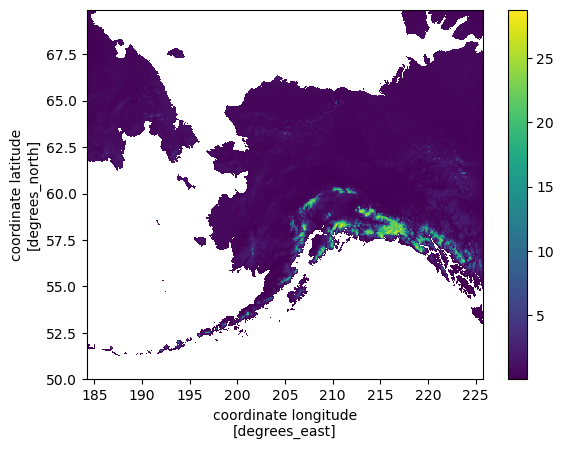

In [18]:
# Check April mean
april_mean.plot()

## 2009 - Flood in Eagle

### Find grid point closest to village

In [19]:
# Coordinates for village
lat_village = 64.786022 
lon_village = -141.199917
village_name = 'Eagle'
yy = 2009

In [20]:
# First, find the index of the grid point nearest a specific lat/lon.   
abslat = np.abs(lat_2d - lat_village)
abslon = np.abs(lon_2d - lon_village)
c = np.maximum(abslon, abslat)

# find the smallest values
([xloc], [yloc]) = np.where(c == np.min(c))

# print index values
print(xloc,yloc)

372 552


In [21]:
print(lat_2d[xloc,yloc].values)
print(lon_2d[xloc,yloc].values)

64.79025
-141.18173


### Find the annual snow depth this year

In [22]:
# Create a mask for flood year only
april_yyyy_mask = (snow_depth.time.dt.month == 4) & (snow_depth.time.dt.year == yy)

# Subset the data
april_yyyy_snow = snow_depth.sel(time=april_yyyy_mask)

# Compute mean snow depth over flood year
mean_snow_april_yyyy = april_yyyy_snow.mean(dim="time")

# Inspect or plot
print(mean_snow_april_yyyy)

<xarray.DataArray 'SNOW_DEPTH' (lat: 662, lon: 782)> Size: 2MB
dask.array<mean_agg-aggregate, shape=(662, 782), dtype=float32, chunksize=(662, 782), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float32 3kB 184.2 184.3 184.3 184.4 ... 225.7 225.7 225.8
  * lat      (lat) float32 3kB 50.01 50.04 50.07 50.11 ... 69.83 69.86 69.89


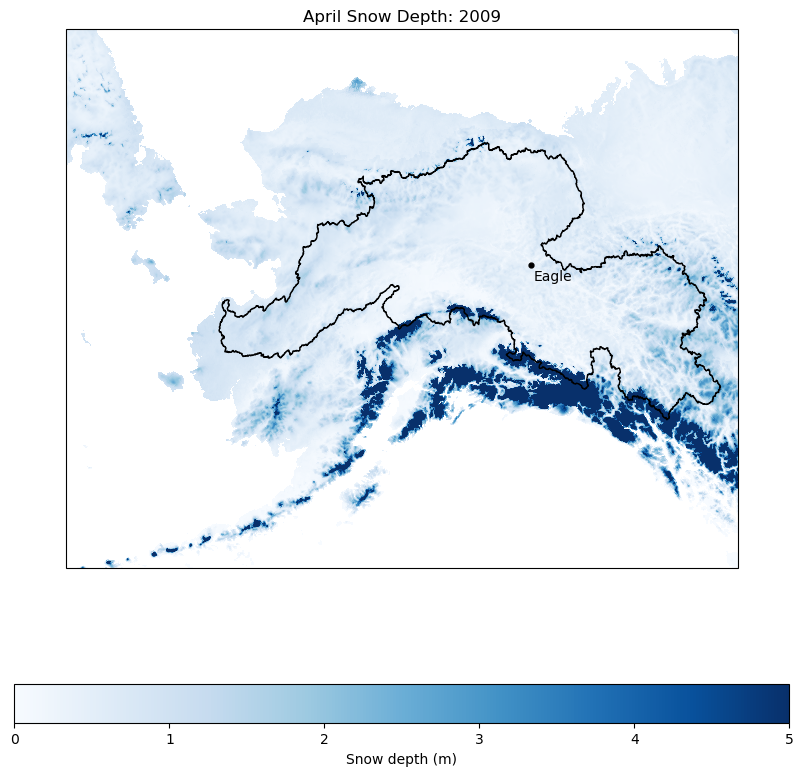

In [23]:
# Plot Raw Snow Depth for this year

fig = plt.figure(figsize=(10,10))
cmap = plt.colormaps['RdBu_r']

ax = plt.subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude=-150.0))
ax.set_extent([-170, -132, 55, 72], crs=ccrs.PlateCarree())

cs0 = ax.pcolormesh(lon_2d, lat_2d,
                    mean_snow_april_yyyy,
                    vmin = 0, vmax = 5,
                    cmap='Blues', 
                    transform=ccrs.PlateCarree())

cbar = fig.colorbar(cs0, ax=ax, orientation='horizontal',label='Snow depth (m)')
ax.set_title('April Snow Depth: '+str(yy))

# Add shapefile boundary
ax.add_geometries(yukon.geometry, crs=ccrs.PlateCarree(),
                  edgecolor='black', facecolor='none', linewidth=1)

# Add point
ax.plot(lon_2d[xloc, yloc].values, lat_2d[xloc, yloc].values, marker='.', color='black', markersize=7, transform=ccrs.PlateCarree())
ax.text(lon_2d[xloc, yloc].values, lat_2d[xloc, yloc].values - 0.5, village_name, color='black', transform=ccrs.PlateCarree())

plt.show()

### Find the snow depth anomaly this year compared to historical (1995-2005) mean

In [24]:
# Calculate flood year anomaly
april_yyyy_anom = april_yyyy_snow - april_mean

In [25]:
april_yyyy_anom = april_yyyy_anom.isel(time=0)

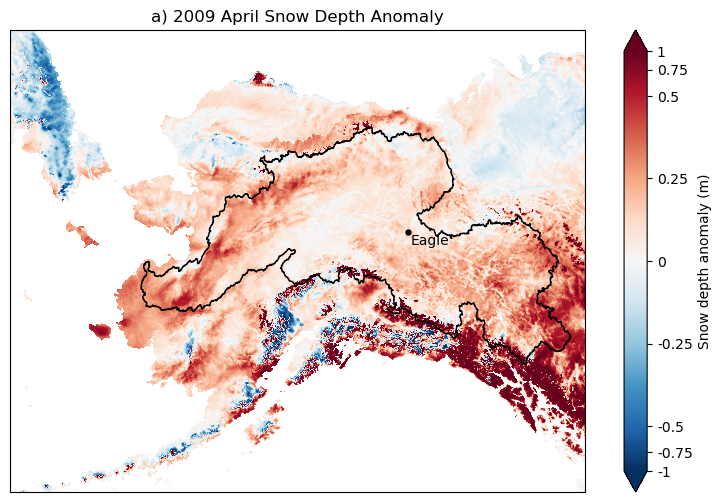

In [26]:
# Plot Snow Depth Anomaly for this year - including place name

fout = 'snow_anomaly_'+str(yy)+'.png'

fig = plt.figure(figsize=(10,6))
cmap = plt.colormaps['RdBu_r']

ax = plt.subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude=-150.0))
ax.set_extent([-170, -132, 55, 72], crs=ccrs.PlateCarree())

norm = SymLogNorm(linthresh=0.5, linscale=1, vmin=-1, vmax=1)
ticks = [-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]
labels = ['-1', '-0.75', '-0.5', '-0.25', '0', '0.25', '0.5', '0.75', '1']
#norm = SymLogNorm(linthresh=0.5, linscale=1, vmin=-4, vmax=4)
#ticks = [-4, -2, -1, 0, 1, 2, 4]
#labels = ['-4', '-2', '-1', '0', '1', '2', '4']

cs0 = ax.pcolormesh(
    lon_2d, lat_2d,
    april_yyyy_anom,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)

cbar = fig.colorbar(cs0, ax=ax, extend = 'both', label='Snow depth anomaly (m)')
cbar.ax.yaxis.set_major_locator(FixedLocator(ticks))
cbar.ax.yaxis.set_major_formatter(FixedFormatter(labels))
cbar.ax.minorticks_off()

ax.set_title('a) '+str(yy)+' April Snow Depth Anomaly')

ax.add_geometries(
    yukon.geometry,
    crs=ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=1
)

ax.plot(
    lon_2d[xloc, yloc].values,
    lat_2d[xloc, yloc].values,
    marker='.',
    color='black',
    markersize=7,
    transform=ccrs.PlateCarree()
)

ax.text(
    lon_2d[xloc, yloc].values,
    lat_2d[xloc, yloc].values - 0.5,
    village_name,
    color='black',
    transform=ccrs.PlateCarree()
)
plt.savefig(fout, bbox_inches="tight")
plt.show()


### Plot the distribution of values in Village 1995-2020

In [27]:
# Subset specific years in Village
subset_years = (ds_april['years'] >= 1995) & (ds_april['years'] <= 2020)
village_series_subset = ds_april[subset_years, xloc, yloc]

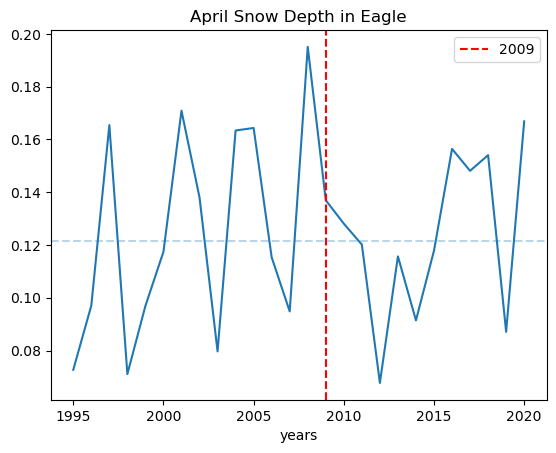

In [28]:
# Plot April snow depth time series

village_series_subset.plot()
plt.title('April Snow Depth in '+village_name)

# Add vertical line at year 2009
plt.axvline(x=yy, color='red', linestyle='--', label=str(yy))

# Add horizontal line for mean April snow depth (1995–2005 baseline)
village_mean = april_mean[xloc, yloc].values
plt.axhline(y=village_mean, linestyle='--', alpha=0.3)

# Add legend
plt.legend()

# Show the plot
plt.show()

In [29]:
# Check if flood year was an outlier

# Separate flood year 
value_yyyy = village_series_subset.sel(years = yy)

# Perform one-sample t-test
t_stat, p_value = ttest_1samp(village_series_subset, value_yyyy)

print(f"Flood year Snow Depth: {value_yyyy:.2f}")
print(f"Mean of other years: {np.mean(village_series_subset):.2f}")
print(f"T-statistic: {t_stat:.2f}, p-value: {p_value:.2e}")


Flood year Snow Depth: 0.14
Mean of other years: 0.12
T-statistic: -1.79, p-value: 8.58e-02


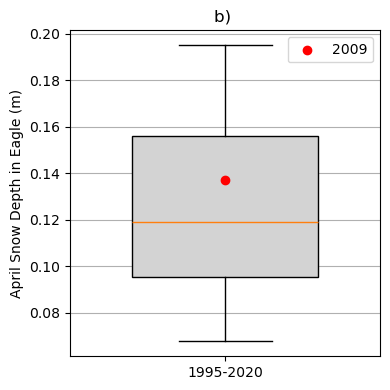

In [30]:
# Plot Box and Whisker of April Snow Depth distribution
fout = 'snow_distribution_'+village_name+'_'+str(yy)+'.png'

plt.figure(figsize=(4, 4))
plt.boxplot(village_series_subset, positions=[0], widths=0.6, patch_artist=True, boxprops=dict(facecolor='lightgray'))
plt.scatter([0], [value_yyyy], color='red', label=str(yy), zorder=10)
plt.ylabel(r'April Snow Depth in '+village_name+' (m)')
plt.title('b) ')
plt.xticks([0], ['1995-2020'])
plt.grid(True, axis='y')
plt.legend()
plt.tight_layout()
plt.savefig(fout, bbox_inches='tight')
plt.show()


## 2013 - Flood in Galena

### Find grid point closest to village

In [31]:
# Coordinates for village
lat_village = 64.740643 
lon_village = -156.885462
village_name = 'Galena'
yy = 2013

In [32]:
# First, find the index of the grid point nearest a specific lat/lon.   
abslat = np.abs(lat_2d - lat_village)
abslon = np.abs(lon_2d - lon_village)
c = np.maximum(abslon, abslat)

# find the smallest values
([xloc], [yloc]) = np.where(c == np.min(c))

# print index values
print(xloc,yloc)

351 368


In [33]:
print(lat_2d[xloc,yloc].values)
print(lon_2d[xloc,yloc].values)

64.725174
-156.90182


### Find the annual snow depth this year

In [34]:
# Create a mask for flood year only
april_yyyy_mask = (snow_depth.time.dt.month == 4) & (snow_depth.time.dt.year == yy)

# Subset the data
april_yyyy_snow = snow_depth.sel(time=april_yyyy_mask)

# Compute mean snow depth over flood year
mean_snow_april_yyyy = april_yyyy_snow.mean(dim="time")

# Inspect or plot
print(mean_snow_april_yyyy)

<xarray.DataArray 'SNOW_DEPTH' (lat: 662, lon: 782)> Size: 2MB
dask.array<mean_agg-aggregate, shape=(662, 782), dtype=float32, chunksize=(662, 782), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float32 3kB 184.2 184.3 184.3 184.4 ... 225.7 225.7 225.8
  * lat      (lat) float32 3kB 50.01 50.04 50.07 50.11 ... 69.83 69.86 69.89


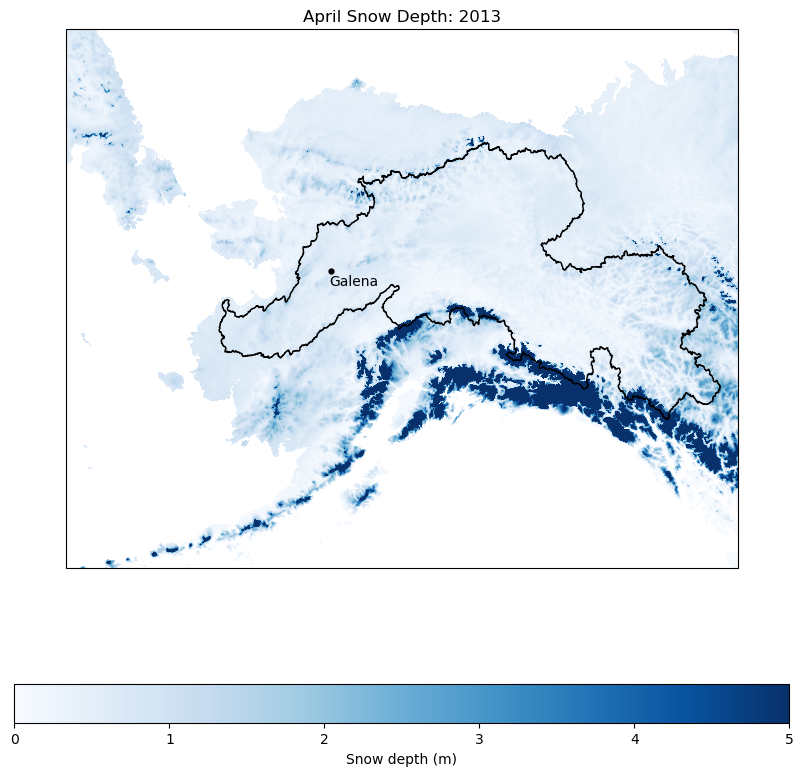

In [35]:
# Plot Raw Snow Depth for this year

fig = plt.figure(figsize=(10,10))
cmap = plt.colormaps['RdBu_r']

ax = plt.subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude=-150.0))
ax.set_extent([-170, -132, 55, 72], crs=ccrs.PlateCarree())

cs0 = ax.pcolormesh(lon_2d, lat_2d,
                    mean_snow_april_yyyy,
                    vmin = 0, vmax = 5,
                    cmap='Blues', 
                    transform=ccrs.PlateCarree())

cbar = fig.colorbar(cs0, ax=ax, orientation='horizontal',label='Snow depth (m)')
ax.set_title('April Snow Depth: '+str(yy))

# Add shapefile boundary
ax.add_geometries(yukon.geometry, crs=ccrs.PlateCarree(),
                  edgecolor='black', facecolor='none', linewidth=1)

# Add point
ax.plot(lon_2d[xloc, yloc].values, lat_2d[xloc, yloc].values, marker='.', color='black', markersize=7, transform=ccrs.PlateCarree())
ax.text(lon_2d[xloc, yloc].values, lat_2d[xloc, yloc].values - 0.5, village_name, color='black', transform=ccrs.PlateCarree())

plt.show()

### Find the snow depth anomaly this year compared to historical (1995-2005) mean

In [36]:
# Calculate flood year anomaly
april_yyyy_anom = april_yyyy_snow - april_mean

In [37]:
april_yyyy_anom = april_yyyy_anom.isel(time=0)

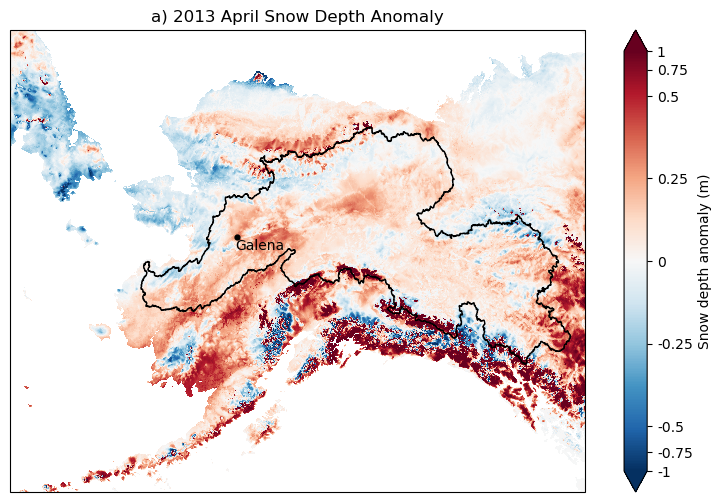

In [38]:
# Plot Snow Depth Anomaly for this year - including place name

fout = 'snow_anomaly_'+str(yy)+'.png'

fig = plt.figure(figsize=(10,6))
cmap = plt.colormaps['RdBu_r']

ax = plt.subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude=-150.0))
ax.set_extent([-170, -132, 55, 72], crs=ccrs.PlateCarree())

norm = SymLogNorm(linthresh=0.5, linscale=1, vmin=-1, vmax=1)
ticks = [-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]
labels = ['-1', '-0.75', '-0.5', '-0.25', '0', '0.25', '0.5', '0.75', '1']
#norm = SymLogNorm(linthresh=0.5, linscale=1, vmin=-4, vmax=4)
#ticks = [-4, -2, -1, 0, 1, 2, 4]
#labels = ['-4', '-2', '-1', '0', '1', '2', '4']

cs0 = ax.pcolormesh(
    lon_2d, lat_2d,
    april_yyyy_anom,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)

cbar = fig.colorbar(cs0, ax=ax, extend = 'both', label='Snow depth anomaly (m)')
cbar.ax.yaxis.set_major_locator(FixedLocator(ticks))
cbar.ax.yaxis.set_major_formatter(FixedFormatter(labels))
cbar.ax.minorticks_off()

ax.set_title('a) '+str(yy)+' April Snow Depth Anomaly')

ax.add_geometries(
    yukon.geometry,
    crs=ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=1
)

ax.plot(
    lon_2d[xloc, yloc].values,
    lat_2d[xloc, yloc].values,
    marker='.',
    color='black',
    markersize=7,
    transform=ccrs.PlateCarree()
)

ax.text(
    lon_2d[xloc, yloc].values,
    lat_2d[xloc, yloc].values - 0.5,
    village_name,
    color='black',
    transform=ccrs.PlateCarree()
)
plt.savefig(fout, bbox_inches="tight")
plt.show()


### Plot the distribution of values in Village 1995-2020

In [39]:
# Subset specific years in Village
subset_years = (ds_april['years'] >= 1995) & (ds_april['years'] <= 2020)
village_series_subset = ds_april[subset_years, xloc, yloc]

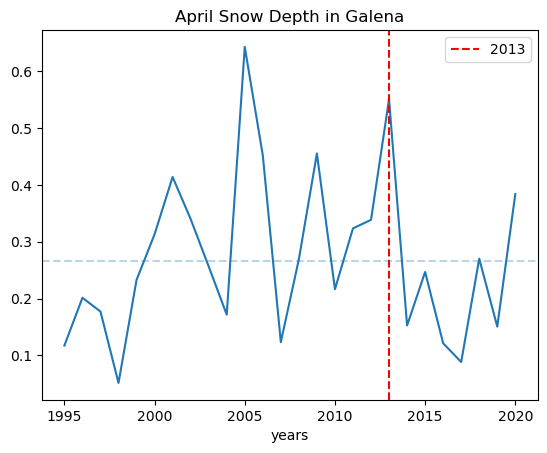

In [40]:
# Plot April snow depth time series

village_series_subset.plot()
plt.title('April Snow Depth in '+village_name)

# Add vertical line at year 2009
plt.axvline(x=yy, color='red', linestyle='--', label=str(yy))

# Add horizontal line for mean April snow depth (1995–2005 baseline)
village_mean = april_mean[xloc, yloc].values
plt.axhline(y=village_mean, linestyle='--', alpha=0.3)

# Add legend
plt.legend()

# Show the plot
plt.show()

In [41]:
# Check if flood year was an outlier

# Separate flood year 
value_yyyy = village_series_subset.sel(years = yy)

# Perform one-sample t-test
t_stat, p_value = ttest_1samp(village_series_subset, value_yyyy)

print(f"Flood year Snow Depth: {value_yyyy:.2f}")
print(f"Mean of other years: {np.mean(village_series_subset):.2f}")
print(f"T-statistic: {t_stat:.2f}, p-value: {p_value:.2e}")


Flood year Snow Depth: 0.55
Mean of other years: 0.27
T-statistic: -9.71, p-value: 5.77e-10


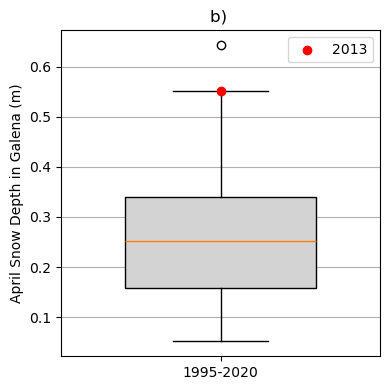

In [42]:
# Plot Box and Whisker of April Snow Depth distribution
fout = 'snow_distribution_'+village_name+'_'+str(yy)+'.png'

plt.figure(figsize=(4, 4))
plt.boxplot(village_series_subset, positions=[0], widths=0.6, patch_artist=True, boxprops=dict(facecolor='lightgray'))
plt.scatter([0], [value_yyyy], color='red', label=str(yy), zorder=10)
plt.ylabel(r'April Snow Depth in '+village_name+' (m)')
plt.title('b) ')
plt.xticks([0], ['1995-2020'])
plt.grid(True, axis='y')
plt.legend()
plt.tight_layout()
plt.savefig(fout, bbox_inches='tight')
plt.show()
